# Cellpose Documentation Figure Generation

This notebook generates figures for `docs/cellpose_comparison.md` showing:
1. Suite2p preprocessing steps (binning, denoising, HP filtering)
2. Anatomical mode image comparisons
3. Direct vs Suite2p segmentation results

Figures are saved to `docs/_images/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, uniform_filter1d
from mbo_utilities import imread

# output directory for figures
DOCS_IMAGES = Path("../../docs/_images")
DOCS_IMAGES.mkdir(exist_ok=True)

# figure settings
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

## Load Sample Data

Load a sample dataset for demonstrations. Update the path to your data.

In [2]:
# update this path to your data
DATA_PATH = Path(r"D:\cj\2025-11-21\vDAQ0_000_000_000.tif")

if DATA_PATH.exists():
    arr = imread(DATA_PATH, fix_phase=True, use_fft=True)
    print(f"Loaded: {arr.shape}")

    # extract a single plane if volumetric
    if len(arr.shape) == 4:
        plane_idx = 0
        data = arr[:, plane_idx, :, :]
    else:
        data = arr[:]

    # convert to numpy
    data = np.asarray(data).astype(np.float32)
    print(f"Working data shape: {data.shape}")
else:
    # create synthetic data for demonstration
    print("Creating synthetic data for demonstration...")
    np.random.seed(42)
    nframes, ly, lx = 500, 256, 256

    # create background with slow drift
    t = np.arange(nframes)
    baseline_drift = 100 + 20 * np.sin(2 * np.pi * t / nframes)
    data = np.zeros((nframes, ly, lx), dtype=np.float32)
    data += baseline_drift[:, None, None]

    # add some "cells" with transient activity
    n_cells = 30
    for _ in range(n_cells):
        cy, cx = np.random.randint(20, ly-20), np.random.randint(20, lx-20)
        radius = np.random.randint(4, 8)
        y, x = np.ogrid[:ly, :lx]
        mask = ((y - cy)**2 + (x - cx)**2) < radius**2

        # random transient times
        for _ in range(np.random.randint(3, 10)):
            t_event = np.random.randint(0, nframes - 20)
            amplitude = np.random.uniform(50, 150)
            decay = np.exp(-np.arange(20) / 5)
            data[t_event:t_event+20, mask] += amplitude * decay[:, None]

    # add noise
    data += np.random.randn(*data.shape) * 10
    data = np.clip(data, 0, None)
    print(f"Synthetic data shape: {data.shape}")

Creating synthetic data for demonstration...
Synthetic data shape: (500, 256, 256)


## Figure 1: Suite2p Pipeline Overview

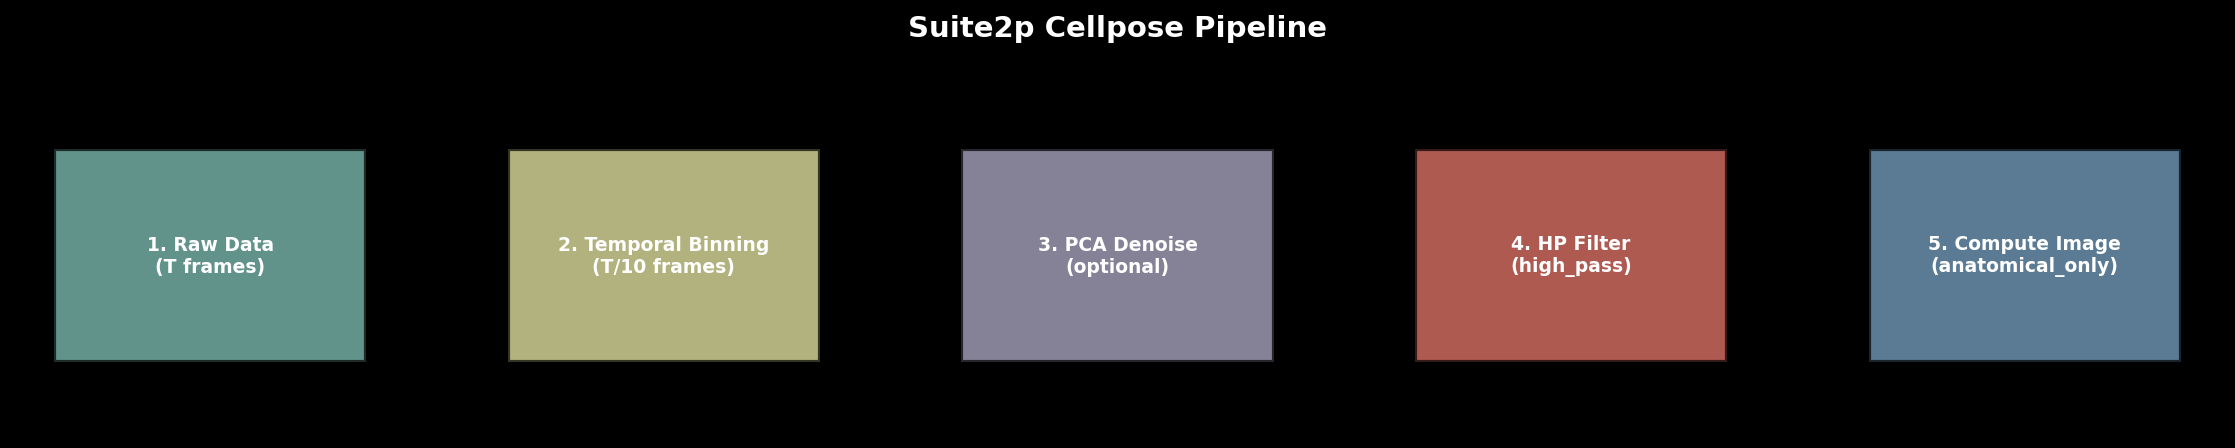

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# step labels
steps = [
    "1. Raw Data\n(T frames)",
    "2. Temporal Binning\n(T/10 frames)",
    "3. PCA Denoise\n(optional)",
    "4. HP Filter\n(high_pass)",
    "5. Compute Image\n(anatomical_only)"
]

# show pipeline steps
for i, (ax, step) in enumerate(zip(axes, steps)):
    ax.add_patch(plt.Rectangle((0.1, 0.2), 0.8, 0.6,
                               facecolor=f'C{i}', alpha=0.7,
                               edgecolor='black', linewidth=2))
    ax.text(0.5, 0.5, step, ha='center', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # add arrow except for last
    if i < len(steps) - 1:
        ax.annotate('', xy=(1.15, 0.5), xytext=(0.95, 0.5),
                   arrowprops=dict(arrowstyle='->', color='black', lw=2),
                   xycoords='axes fraction')

plt.suptitle("Suite2p Cellpose Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_suite2p_pipeline.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 2: Temporal Binning Effect

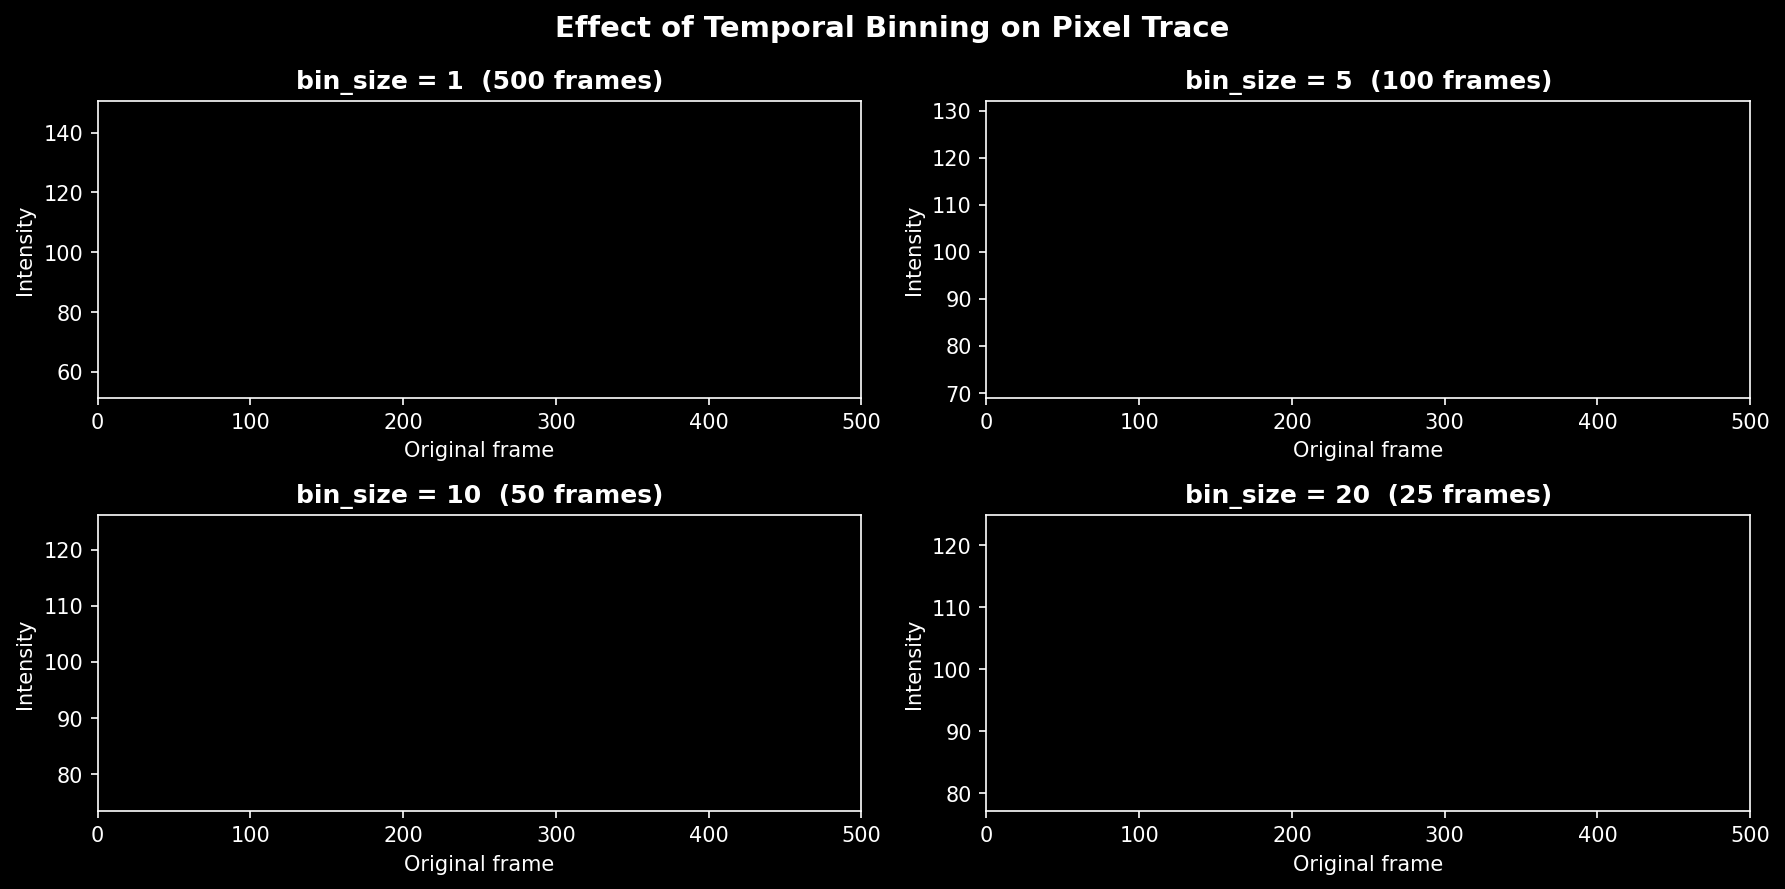

In [4]:
def temporal_bin(mov, bin_size):
    """bin movie in time"""
    n = mov.shape[0] // bin_size * bin_size
    return mov[:n].reshape(-1, bin_size, *mov.shape[1:]).mean(axis=1)

# bin with different sizes
bin_sizes = [1, 5, 10, 20]
binned = {bs: temporal_bin(data, bs) for bs in bin_sizes}

# extract a pixel trace
cy, cx = data.shape[1] // 2, data.shape[2] // 2

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, bs in zip(axes.flat, bin_sizes):
    mov_bin = binned[bs]
    trace = mov_bin[:, cy, cx]
    t = np.arange(len(trace)) * bs

    ax.plot(t, trace, 'k-', lw=0.5, alpha=0.8)
    ax.set_title(f"bin_size = {bs}  ({len(trace)} frames)", fontweight='bold')
    ax.set_xlabel("Original frame")
    ax.set_ylabel("Intensity")
    ax.set_xlim(0, data.shape[0])

plt.suptitle("Effect of Temporal Binning on Pixel Trace", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_temporal_binning.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 3: Temporal High-Pass Filter Effect

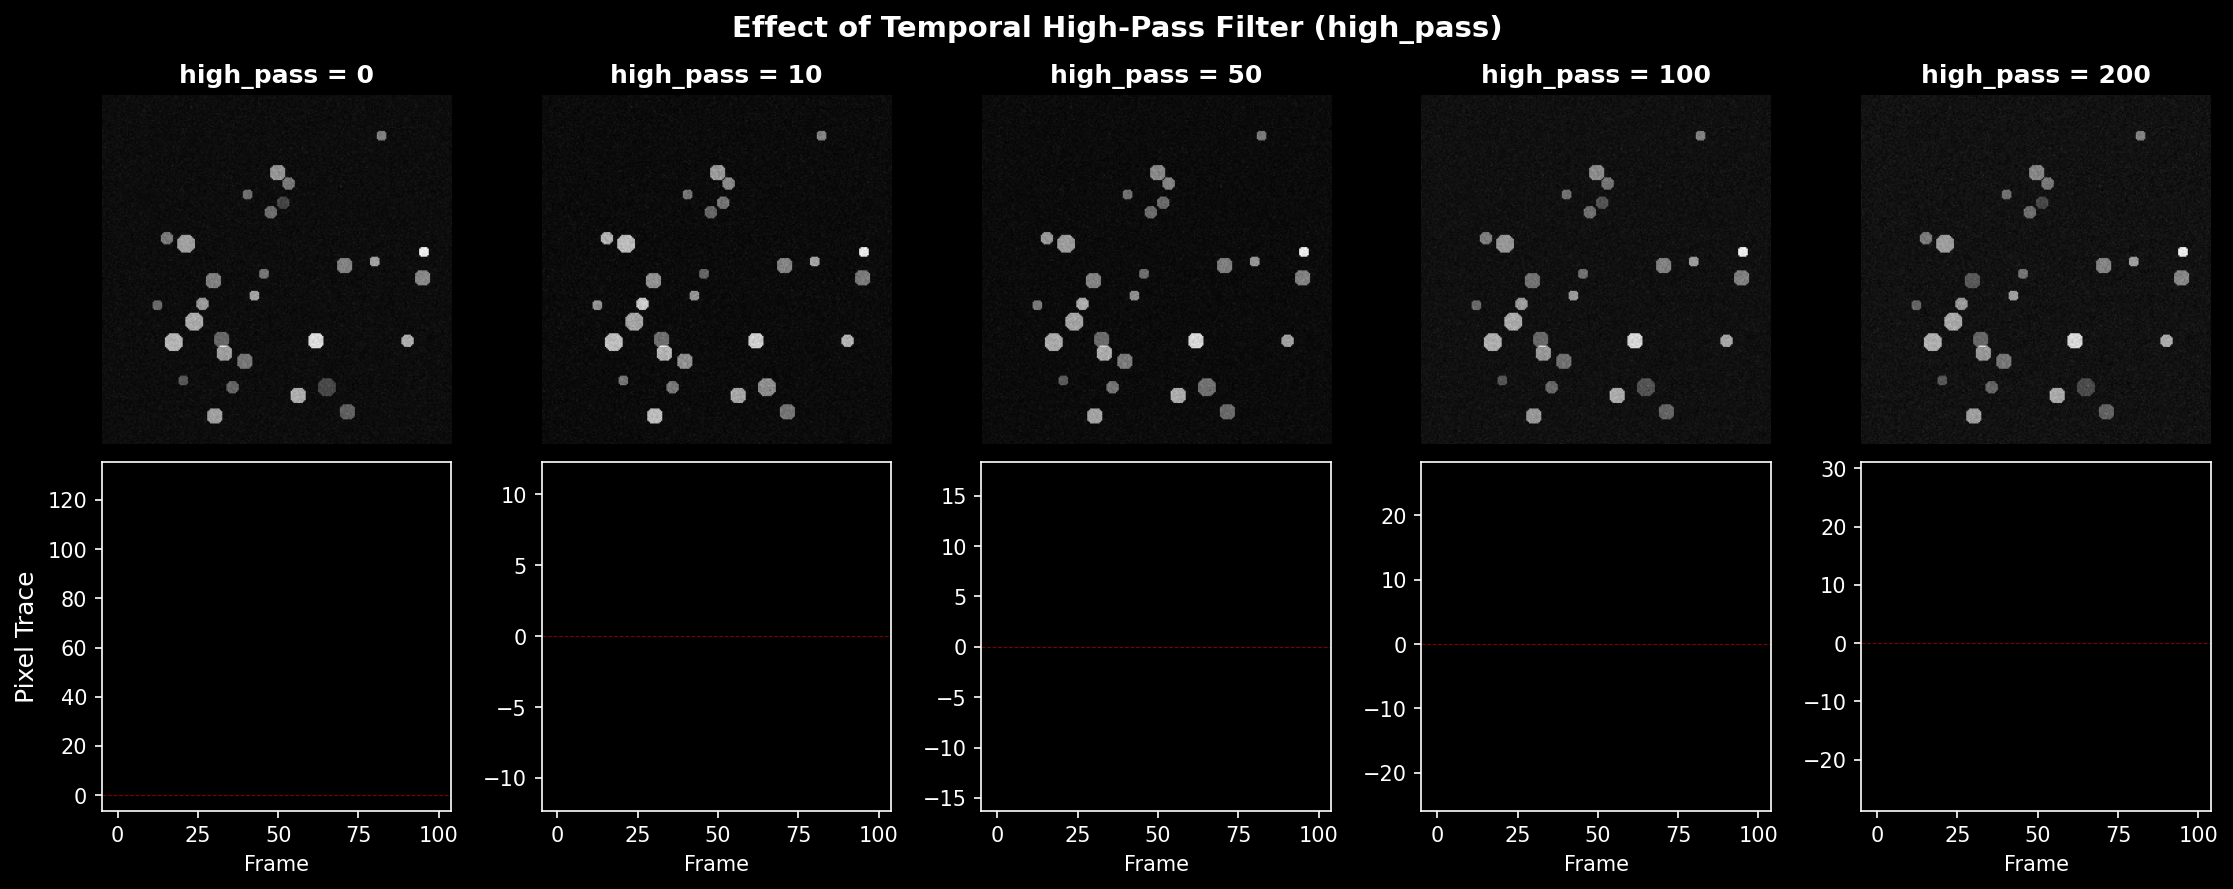

In [5]:
def temporal_high_pass_filter(mov, width):
    """apply temporal high-pass filter (simplified version)"""
    if width <= 0:
        return mov.copy()
    # rolling mean subtraction
    baseline = uniform_filter1d(mov, size=width, axis=0, mode='nearest')
    return mov - baseline

# use binned data for faster processing
mov_bin = binned[5]  # bin_size=5

# different high_pass values
hp_values = [0, 10, 50, 100, 200]

fig, axes = plt.subplots(2, len(hp_values), figsize=(15, 6))

for i, hp in enumerate(hp_values):
    mov_hp = temporal_high_pass_filter(mov_bin, hp)
    max_proj = mov_hp.max(axis=0)

    # show max projection
    im = axes[0, i].imshow(max_proj, cmap='gray')
    axes[0, i].set_title(f"high_pass = {hp}", fontweight='bold')
    axes[0, i].axis('off')

    # show trace
    trace = mov_hp[:, cy, cx]
    axes[1, i].plot(trace, 'k-', lw=0.5)
    axes[1, i].axhline(0, color='r', ls='--', lw=0.5, alpha=0.5)
    axes[1, i].set_xlabel("Frame")
    if i == 0:
        axes[1, i].set_ylabel("Intensity")

axes[0, 0].set_ylabel("Max Proj", fontsize=12)
axes[1, 0].set_ylabel("Pixel Trace", fontsize=12)

plt.suptitle("Effect of Temporal High-Pass Filter (high_pass)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_temporal_hp.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 4: Anatomical Mode Comparison

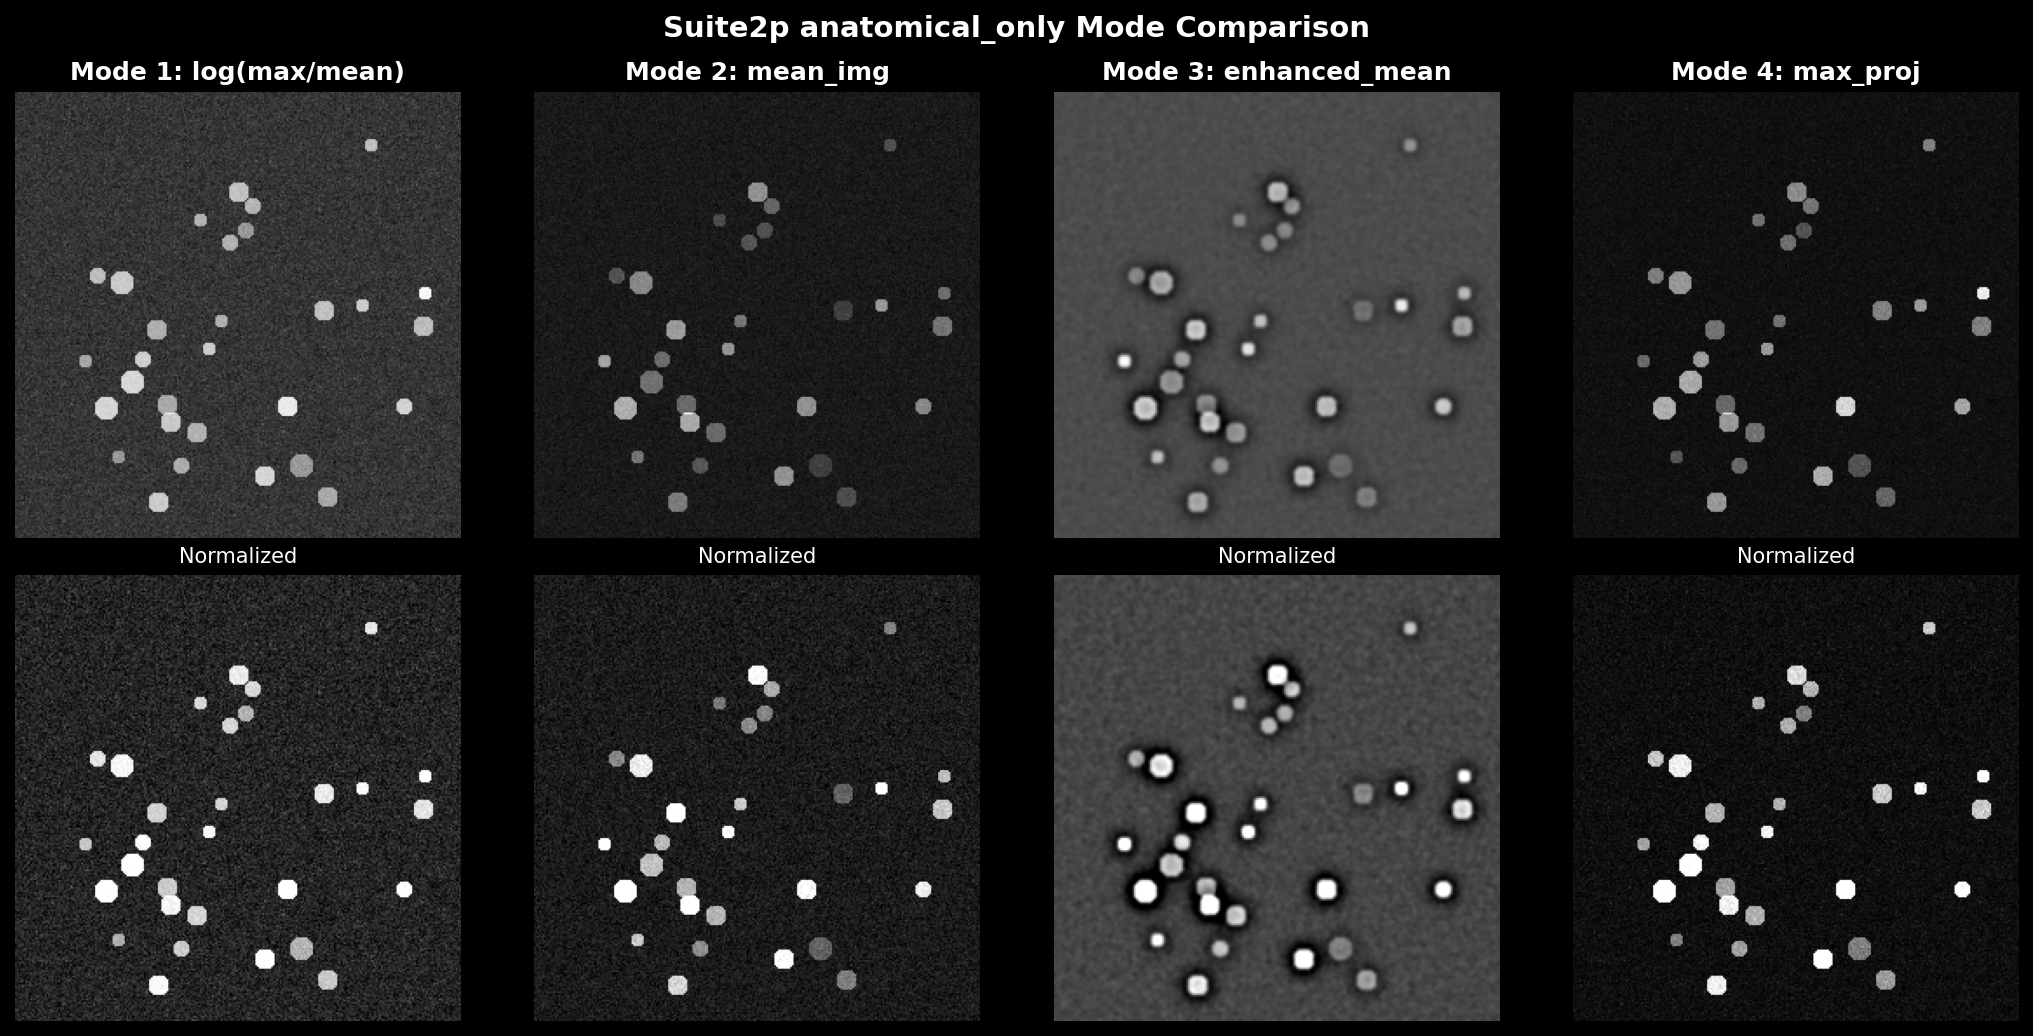

In [6]:
def normalize99(img):
    """normalize to 0-1 using 1st and 99th percentiles"""
    lo, hi = np.percentile(img, [1, 99])
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

# compute images for each anatomical mode
mov_hp = temporal_high_pass_filter(mov_bin, width=100)
mean_img = mov_bin.mean(axis=0)
max_proj = mov_hp.max(axis=0)

# mode 1: log(max_proj / mean_img)
img_mode1 = np.log(np.maximum(1e-3, max_proj / np.maximum(1e-3, mean_img)))

# mode 2: mean_img
img_mode2 = mean_img

# mode 3: enhanced mean (simulated - in practice uses registration correlation)
img_mode3 = gaussian_filter(mean_img, sigma=1) - gaussian_filter(mean_img, sigma=5)

# mode 4: max_proj
img_mode4 = max_proj

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

modes = [
    (1, img_mode1, "log(max/mean)"),
    (2, img_mode2, "mean_img"),
    (3, img_mode3, "enhanced_mean"),
    (4, img_mode4, "max_proj"),
]

for i, (mode_num, img, label) in enumerate(modes):
    # raw image
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Mode {mode_num}: {label}", fontweight='bold')
    axes[0, i].axis('off')

    # normalized for cellpose
    img_norm = normalize99(img)
    axes[1, i].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title("Normalized", fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Raw", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Normalized\n(for Cellpose)", fontsize=12, fontweight='bold')

plt.suptitle("Suite2p anatomical_only Mode Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_anatomical_modes.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 5: Spatial High-Pass Effect

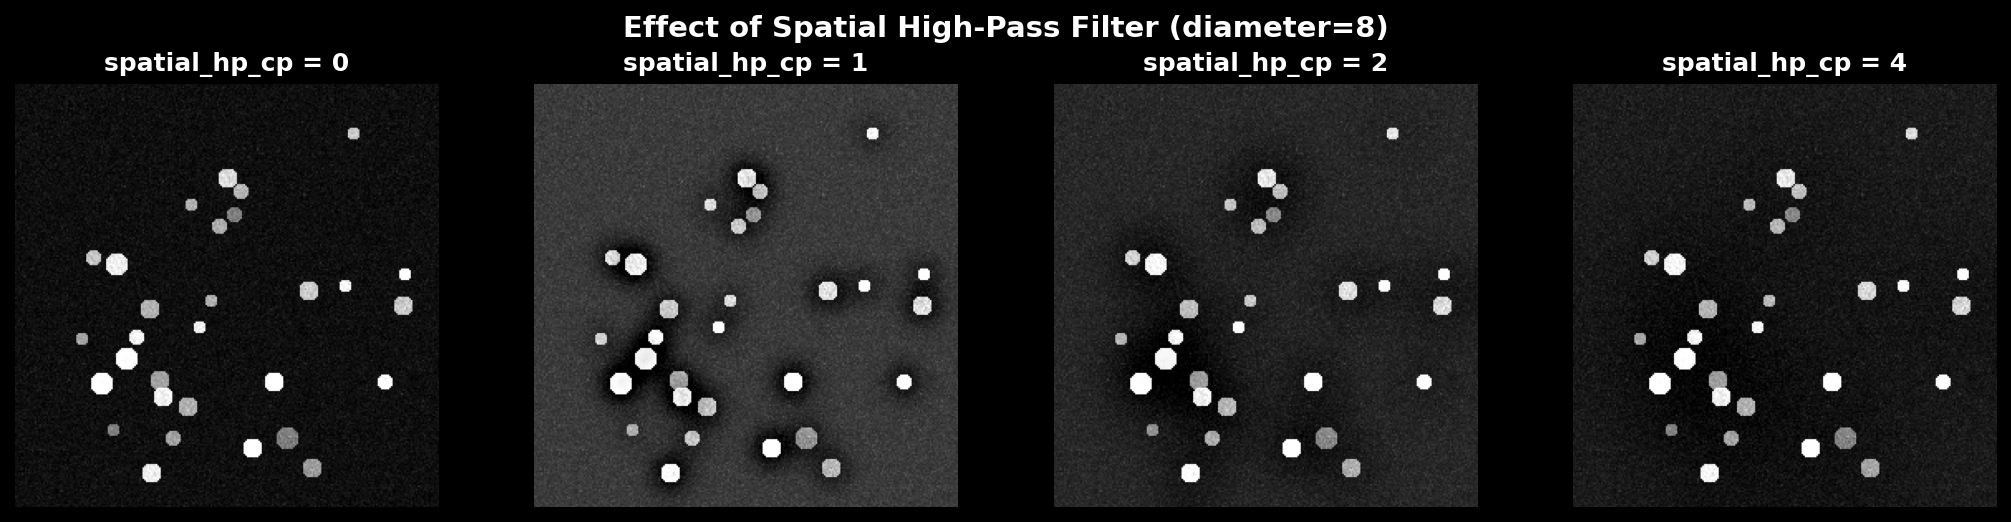

In [7]:
# spatial high-pass with different values
spatial_hp_values = [0, 1, 2, 4]
diameter = 8  # example cell diameter

fig, axes = plt.subplots(1, len(spatial_hp_values), figsize=(14, 3.5))

img = normalize99(max_proj)

for i, shp in enumerate(spatial_hp_values):
    if shp > 0:
        img_hp = img - gaussian_filter(img, diameter * shp)
    else:
        img_hp = img

    axes[i].imshow(normalize99(img_hp), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"spatial_hp_cp = {shp}", fontweight='bold')
    axes[i].axis('off')

plt.suptitle(f"Effect of Spatial High-Pass Filter (diameter={diameter})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_spatial_hp.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 6: Direct Cellpose Pipeline

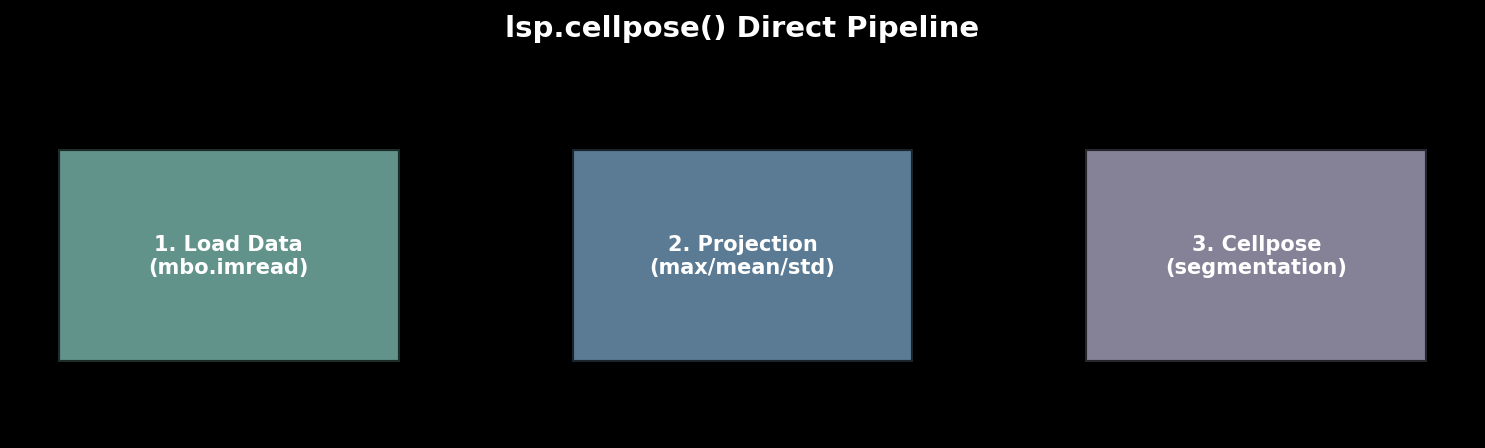

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

steps = [
    "1. Load Data\n(mbo.imread)",
    "2. Projection\n(max/mean/std)",
    "3. Cellpose\n(segmentation)"
]

colors = ['C0', 'C4', 'C2']

for i, (ax, step, color) in enumerate(zip(axes, steps, colors)):
    ax.add_patch(plt.Rectangle((0.1, 0.2), 0.8, 0.6,
                               facecolor=color, alpha=0.7,
                               edgecolor='black', linewidth=2))
    ax.text(0.5, 0.5, step, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    if i < len(steps) - 1:
        ax.annotate('', xy=(1.2, 0.5), xytext=(0.95, 0.5),
                   arrowprops=dict(arrowstyle='->', color='black', lw=2),
                   xycoords='axes fraction')

plt.suptitle("lsp.cellpose() Direct Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_direct_pipeline.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 7: Projection Methods Comparison

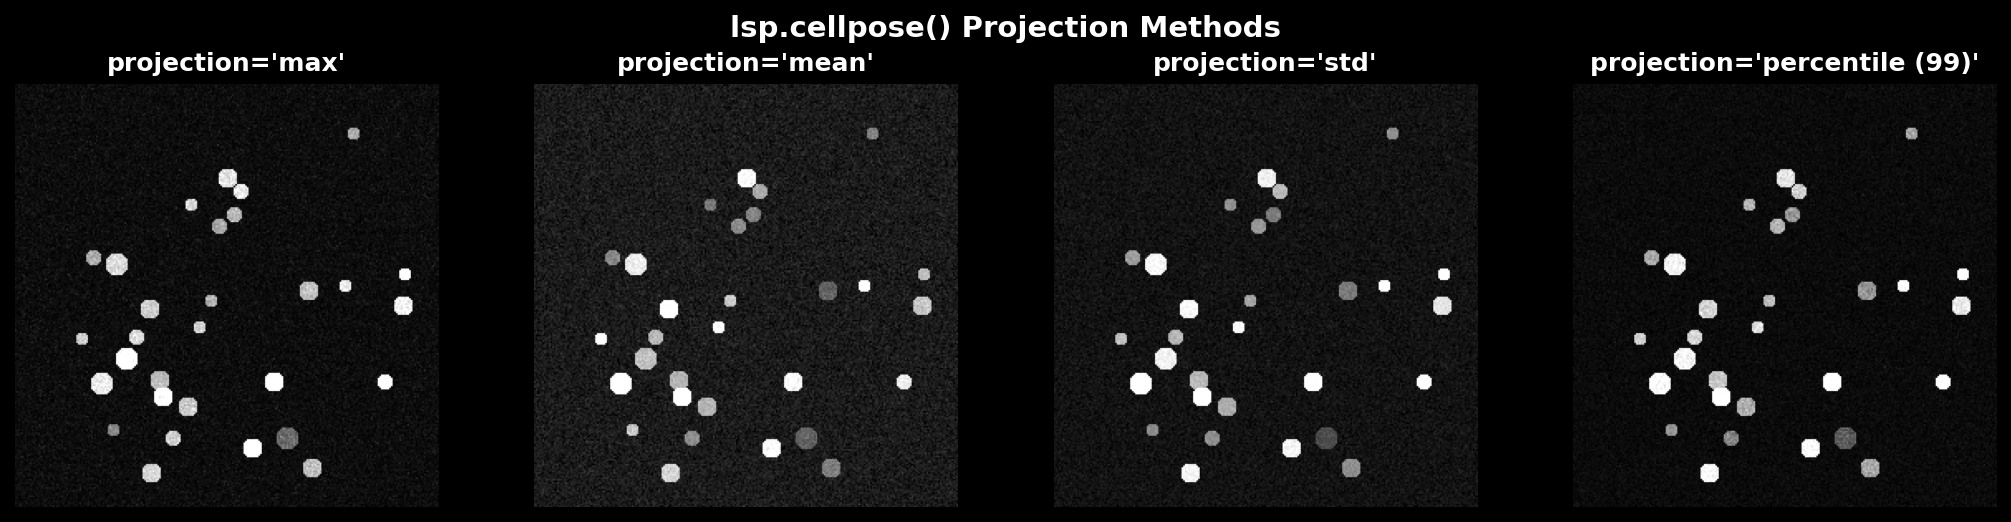

In [9]:
# compute different projections
projections = {
    'max': data.max(axis=0),
    'mean': data.mean(axis=0),
    'std': data.std(axis=0),
    'percentile (99)': np.percentile(data, 99, axis=0),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (name, proj) in zip(axes, projections.items()):
    ax.imshow(normalize99(proj), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"projection='{name}'", fontweight='bold')
    ax.axis('off')

plt.suptitle("lsp.cellpose() Projection Methods", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_IMAGES / "cellpose_projection_methods.png", bbox_inches='tight', facecolor='white')
plt.show()

## Figure 8: Run Cellpose and Compare Results

This cell requires Cellpose to be installed. Skip if not available.

In [10]:
try:
    from cellpose import models, core
    CELLPOSE_AVAILABLE = True
    print(f"Cellpose available, GPU: {core.use_gpu()}")
except ImportError:
    CELLPOSE_AVAILABLE = False
    print("Cellpose not available, skipping segmentation comparison")

Cellpose available, GPU: True


In [11]:
if CELLPOSE_AVAILABLE:
    # load model
    model = models.CellposeModel(model_type='cyto3', gpu=core.use_gpu())

    # prepare images
    images = {
        'Direct (max proj)': normalize99(projections['max']),
        'Suite2p mode 1': normalize99(img_mode1),
        'Suite2p mode 4': normalize99(img_mode4),
    }

    # run cellpose on each
    results = {}
    for name, img in images.items():
        print(f"Running Cellpose on {name}...")
        masks, flows, styles = model.eval(
            img,
            diameter=8,
            flow_threshold=0.4,
            cellprob_threshold=0.0
        )
        results[name] = {
            'img': img,
            'masks': masks,
            'n_cells': int(masks.max())
        }
        print(f"  Found {results[name]['n_cells']} cells")
else:
    # create placeholder
    results = None

model_type argument is not used in v4.0.1+. Ignoring this argument...


Running Cellpose on Direct (max proj)...


Resizing is deprecated in v4.0.1+


  Found 30 cells
Running Cellpose on Suite2p mode 1...


Resizing is deprecated in v4.0.1+


  Found 30 cells
Running Cellpose on Suite2p mode 4...


Resizing is deprecated in v4.0.1+


  Found 30 cells


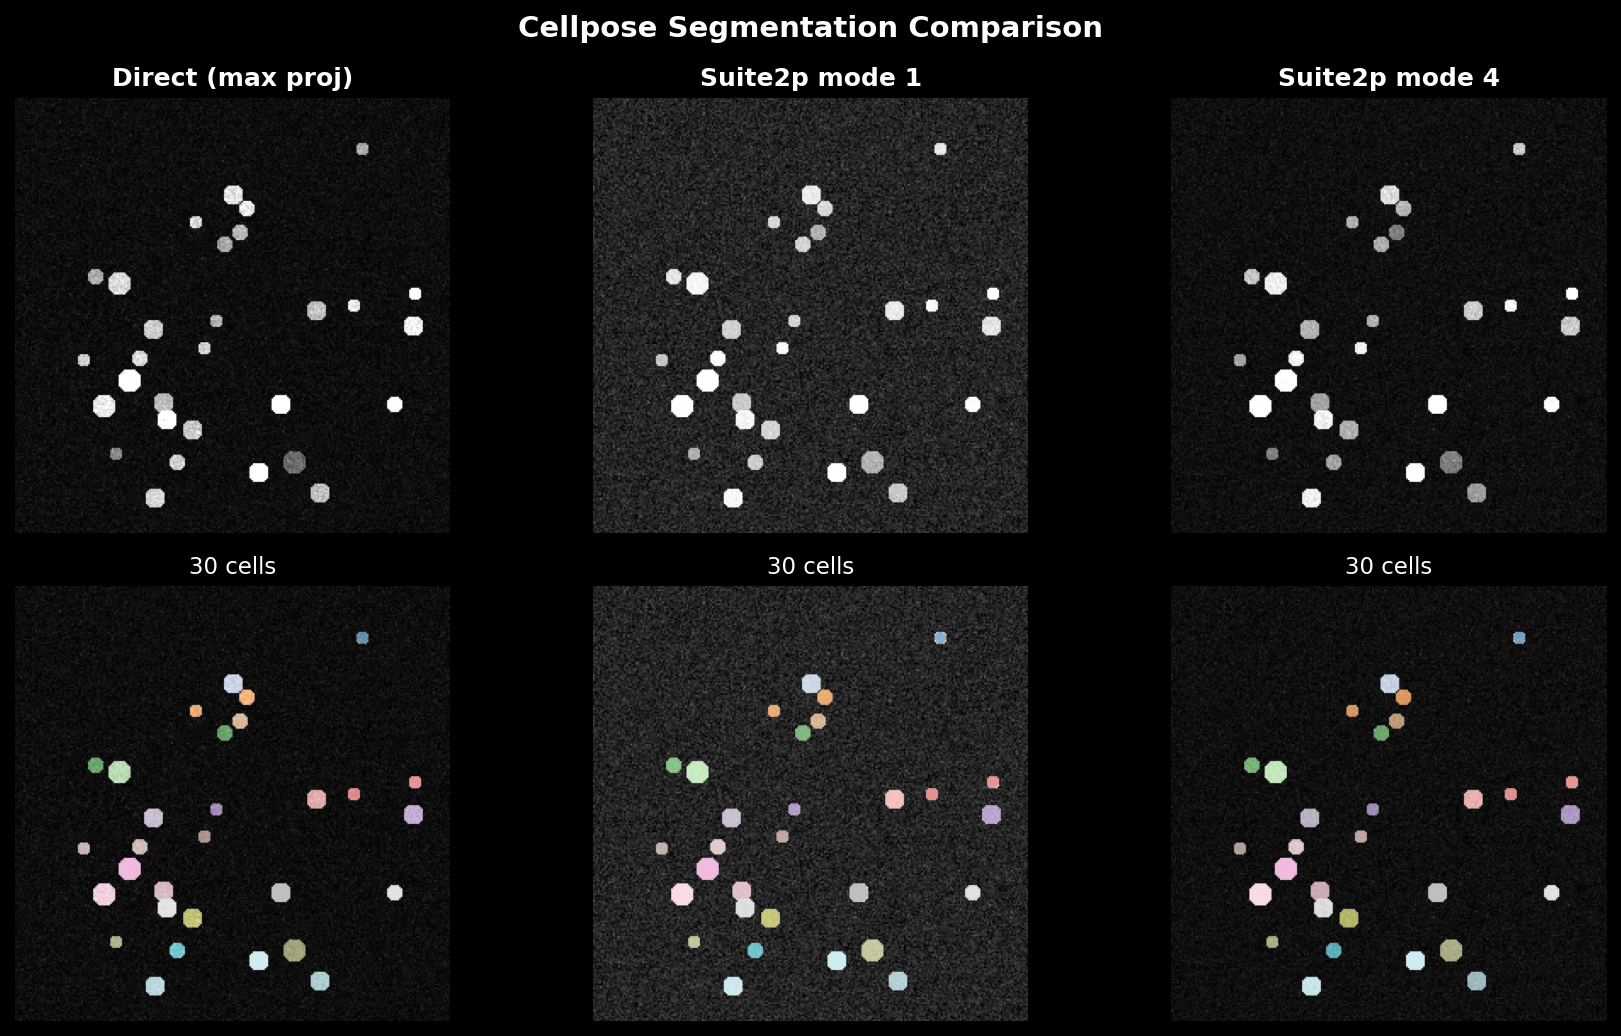

In [12]:
if results is not None:
    fig, axes = plt.subplots(2, len(results), figsize=(12, 7))

    for i, (name, res) in enumerate(results.items()):
        # image
        axes[0, i].imshow(res['img'], cmap='gray')
        axes[0, i].set_title(name, fontweight='bold')
        axes[0, i].axis('off')

        # masks overlay
        from matplotlib.colors import ListedColormap
        n_colors = max(res['masks'].max(), 1)
        colors = plt.cm.tab20(np.linspace(0, 1, n_colors))
        colors[0] = [0, 0, 0, 0]  # transparent background
        cmap = ListedColormap(colors)

        axes[1, i].imshow(res['img'], cmap='gray')
        axes[1, i].imshow(res['masks'], cmap=cmap, alpha=0.5)
        axes[1, i].set_title(f"{res['n_cells']} cells", fontsize=11)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Input Image", fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel("Segmentation", fontsize=12, fontweight='bold')

    plt.suptitle("Cellpose Segmentation Comparison", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DOCS_IMAGES / "cellpose_segmentation_comparison.png", bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Skipping segmentation figure (Cellpose not available)")

## Figure 9: Binning Comparison for Segmentation

Resizing is deprecated in v4.0.1+


bin_size=1: 30 cells


Resizing is deprecated in v4.0.1+


bin_size=5: 30 cells


Resizing is deprecated in v4.0.1+


bin_size=10: 30 cells


Resizing is deprecated in v4.0.1+


bin_size=20: 30 cells


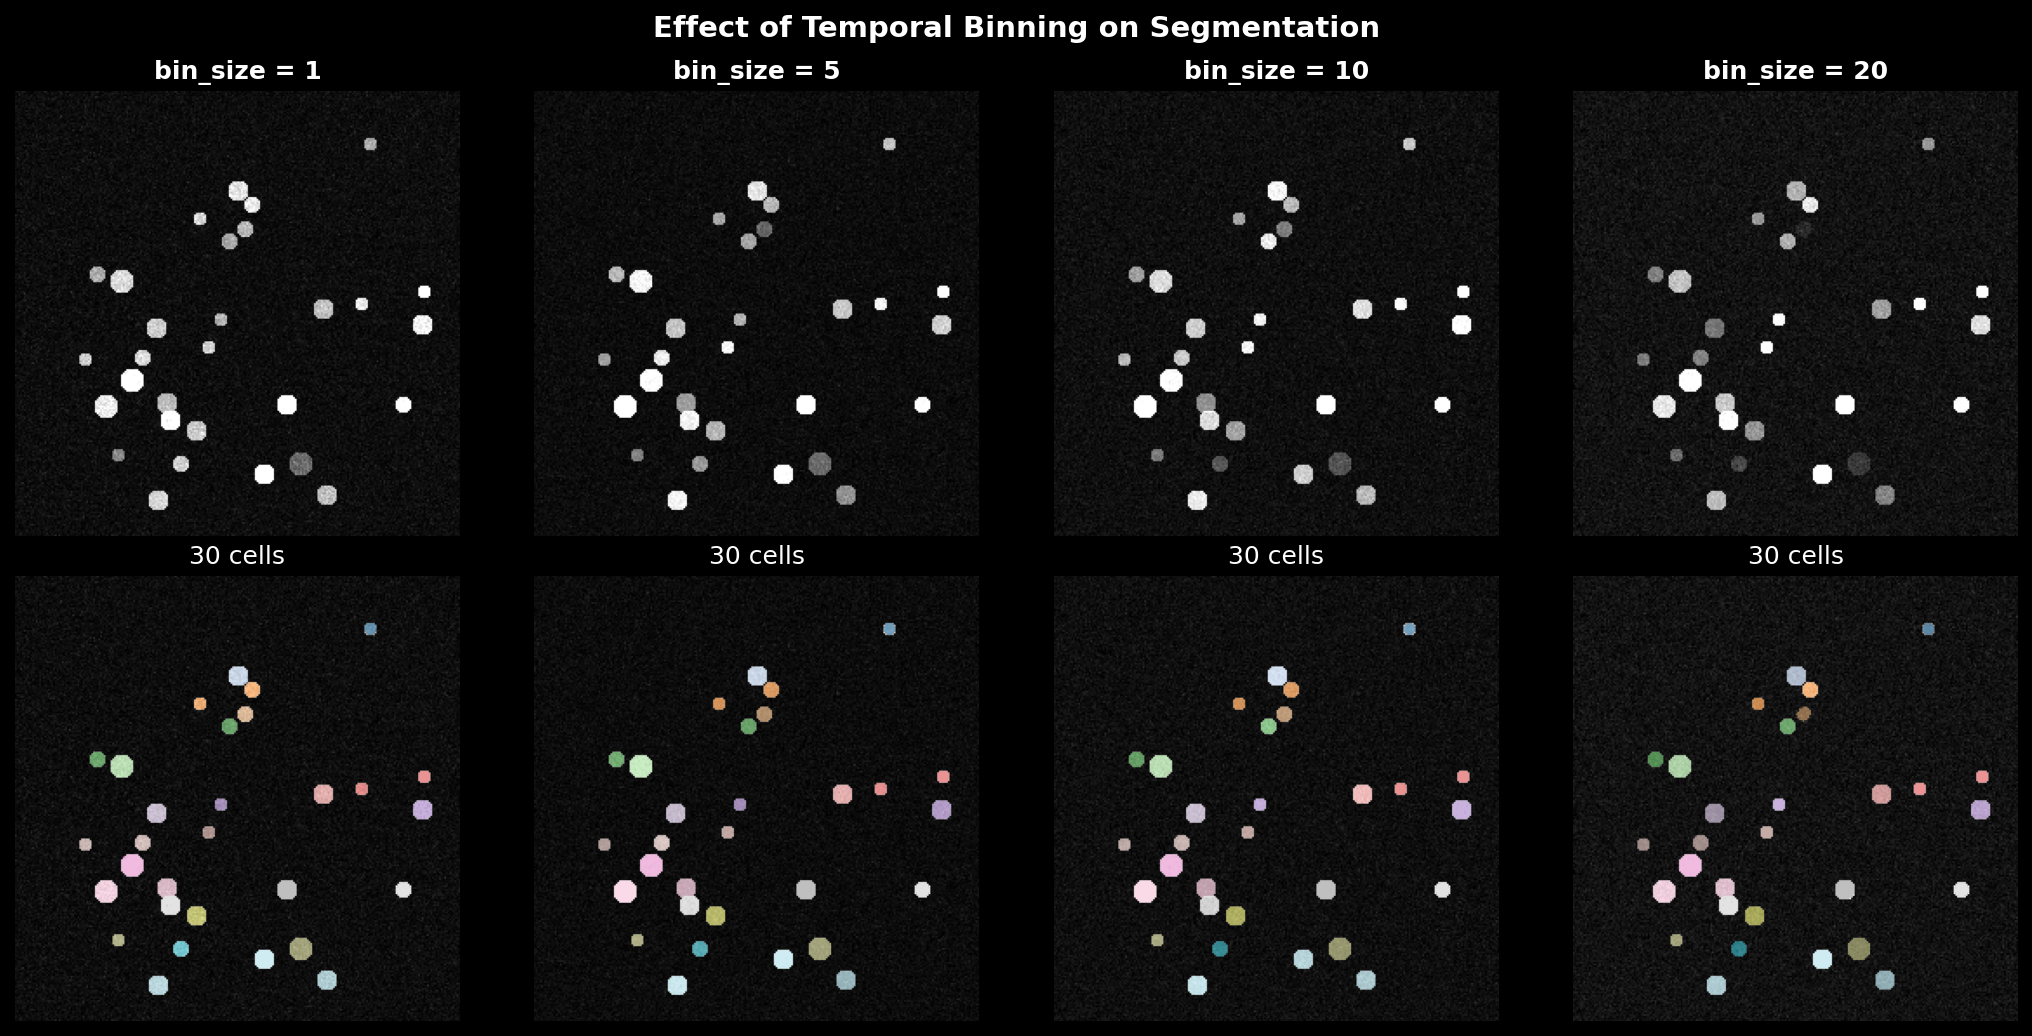

In [13]:
if CELLPOSE_AVAILABLE:
    # compare max proj with different binning
    bin_results = {}
    for bs in [1, 5, 10, 20]:
        mov_bin = temporal_bin(data, bs)
        proj = mov_bin.max(axis=0)
        proj_norm = normalize99(proj)

        masks, flows, styles = model.eval(
            proj_norm, diameter=8, flow_threshold=0.4, cellprob_threshold=0.0
        )
        bin_results[bs] = {
            'img': proj_norm,
            'masks': masks,
            'n_cells': int(masks.max())
        }
        print(f"bin_size={bs}: {bin_results[bs]['n_cells']} cells")

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))

    for i, (bs, res) in enumerate(bin_results.items()):
        axes[0, i].imshow(res['img'], cmap='gray')
        axes[0, i].set_title(f"bin_size = {bs}", fontweight='bold')
        axes[0, i].axis('off')

        axes[1, i].imshow(res['img'], cmap='gray')
        n_colors = max(res['masks'].max(), 1)
        colors = plt.cm.tab20(np.linspace(0, 1, n_colors))
        colors[0] = [0, 0, 0, 0]
        cmap = ListedColormap(colors)
        axes[1, i].imshow(res['masks'], cmap=cmap, alpha=0.5)
        axes[1, i].set_title(f"{res['n_cells']} cells")
        axes[1, i].axis('off')

    plt.suptitle("Effect of Temporal Binning on Segmentation", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DOCS_IMAGES / "cellpose_binning_comparison.png", bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Skipping binning comparison (Cellpose not available)")

## Figure 10: High-Pass Filter Comparison for Segmentation

Resizing is deprecated in v4.0.1+


high_pass=0: 30 cells


Resizing is deprecated in v4.0.1+


high_pass=50: 30 cells


Resizing is deprecated in v4.0.1+


high_pass=100: 30 cells


Resizing is deprecated in v4.0.1+


high_pass=200: 30 cells


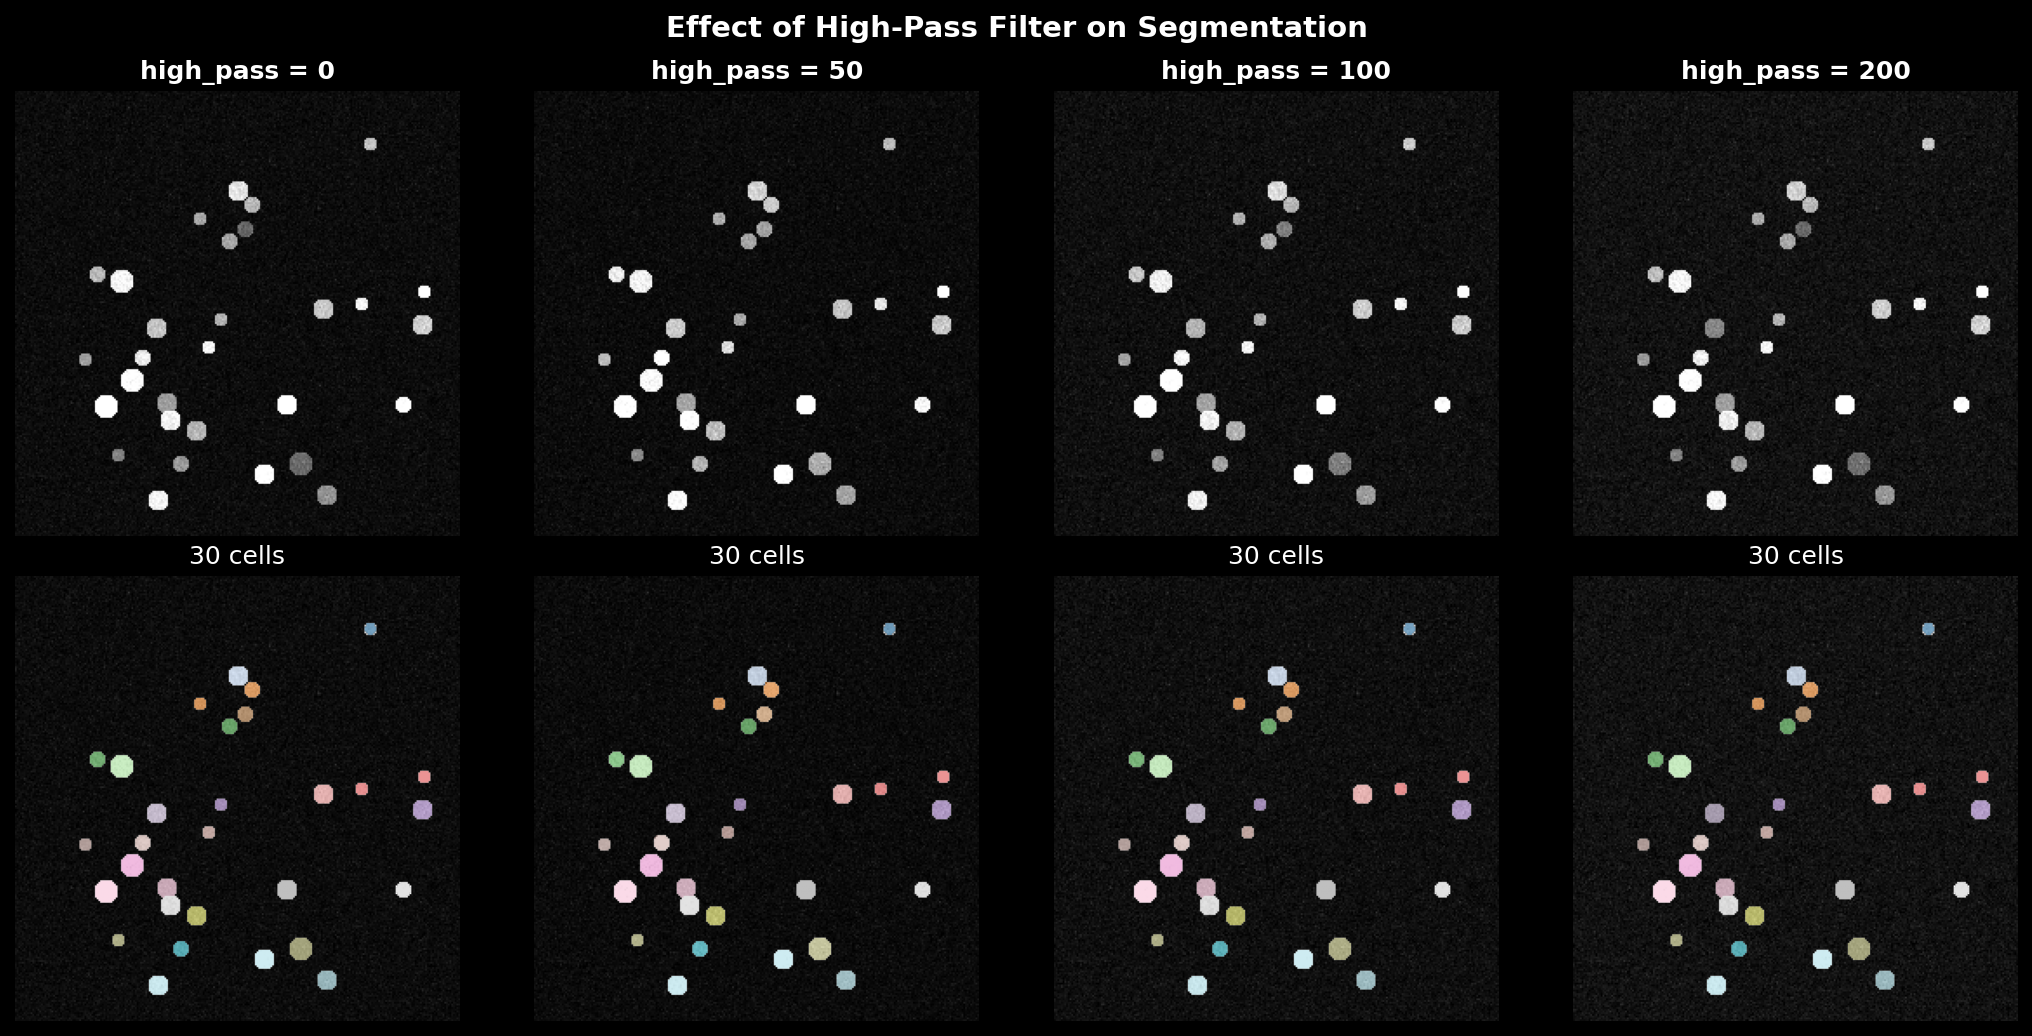

In [14]:
if CELLPOSE_AVAILABLE:
    # compare max proj with different HP values
    hp_results = {}
    mov_bin = temporal_bin(data, 5)

    for hp in [0, 50, 100, 200]:
        mov_hp = temporal_high_pass_filter(mov_bin, hp)
        proj = mov_hp.max(axis=0)
        proj_norm = normalize99(proj)

        masks, flows, styles = model.eval(
            proj_norm, diameter=8, flow_threshold=0.4, cellprob_threshold=0.0
        )
        hp_results[hp] = {
            'img': proj_norm,
            'masks': masks,
            'n_cells': int(masks.max())
        }
        print(f"high_pass={hp}: {hp_results[hp]['n_cells']} cells")

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))

    for i, (hp, res) in enumerate(hp_results.items()):
        axes[0, i].imshow(res['img'], cmap='gray')
        axes[0, i].set_title(f"high_pass = {hp}", fontweight='bold')
        axes[0, i].axis('off')

        axes[1, i].imshow(res['img'], cmap='gray')
        n_colors = max(res['masks'].max(), 1)
        colors = plt.cm.tab20(np.linspace(0, 1, n_colors))
        colors[0] = [0, 0, 0, 0]
        cmap = ListedColormap(colors)
        axes[1, i].imshow(res['masks'], cmap=cmap, alpha=0.5)
        axes[1, i].set_title(f"{res['n_cells']} cells")
        axes[1, i].axis('off')

    plt.suptitle("Effect of High-Pass Filter on Segmentation", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DOCS_IMAGES / "cellpose_hp_comparison.png", bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print("Skipping HP comparison (Cellpose not available)")

## Summary

Generated figures saved to `docs/_images/`:

In [15]:
print("Generated figures:")
for f in sorted(DOCS_IMAGES.glob("cellpose_*.png")):
    print(f"  - {f.name}")

Generated figures:
  - cellpose_anatomical_modes.png
  - cellpose_binning_comparison.png
  - cellpose_direct_pipeline.png
  - cellpose_hp_comparison.png
  - cellpose_projection_methods.png
  - cellpose_segmentation_comparison.png
  - cellpose_spatial_hp.png
  - cellpose_suite2p_pipeline.png
  - cellpose_temporal_binning.png
  - cellpose_temporal_hp.png
